最終課題＿オリジナルAIの構築

In [13]:
!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Path:", path)

Path: C:\Users\boobo\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1


In [14]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 10028 files belonging to 2 classes.
Using 8023 files for training.
Found 10028 files belonging to 2 classes.
Using 2005 files for validation.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


251/251 ━━━━━━━━━━━━━━━━━━━━ 56s 216ms/step - accuracy: 0.7928 - loss: 0.5604 - val_accuracy: 0.7985 - val_loss: 0.5100
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 53s 212ms/step - accuracy: 0.7982 - loss: 0.5172 - val_accuracy: 0.7985 - val_loss: 0.5127
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 205ms/step - accuracy: 0.7982 - loss: 0.5120 - val_accuracy: 0.7985 - val_loss: 0.5111
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 203ms/step - accuracy: 0.7981 - loss: 0.4932 - val_accuracy: 0.7985 - val_loss: 0.5180
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.8001 - loss: 0.4601 - val_accuracy: 0.7985 - val_loss: 0.5828


In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.8153 - loss: 0.4132 - val_accuracy: 0.7910 - val_loss: 0.5833
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 209ms/step - accuracy: 0.8523 - loss: 0.3425 - val_accuracy: 0.7840 - val_loss: 0.7435
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 53s 209ms/step - accuracy: 0.8792 - loss: 0.2823 - val_accuracy: 0.7651 - val_loss: 0.8295
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.9061 - loss: 0.2201 - val_accuracy: 0.7576 - val_loss: 1.0960
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.9303 - loss: 0.1756 - val_accuracy: 0.7461 - val_loss: 1.3170
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.9499 - loss: 0.1260 - val_accuracy: 0.7446 - val_loss: 1.6353
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.9656 - loss: 0.0966 - val_accuracy: 0.7262 - val_loss: 1.5345
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.9695 - loss: 0

In [18]:
loss, accuracy = model.evaluate(val_ds)
print(f"評価結果 - 損失: {loss:.4f}, 精度: {accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.7307 - loss: 2.2336
評価結果 - 損失: 2.2336, 精度: 0.7307


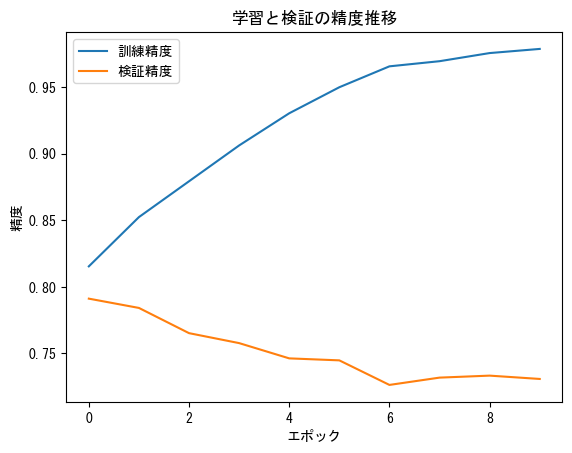

In [20]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'MS Gothic'

plt.plot(history.history['accuracy'], label='訓練精度')
plt.plot(history.history['val_accuracy'], label='検証精度')
plt.xlabel('エポック')
plt.ylabel('精度')
plt.legend()
plt.title('学習と検証の精度推移')
plt.show()